# SVM Exercises

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [4]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

# YOUR CODE HERE
data = pd.read_csv(url,names = names)
invalid = []

invalid = ['plas', 'pres', 'skin', 'test', 'mass']

for i in invalid:
    data[i].replace(to_replace=0, value=np.nan, inplace=True)

data = data.dropna(axis=0).reset_index(drop=True)

data.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
1,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
2,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
3,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
4,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


Split data into training, colidation, and test sets with a test size of 25%

In [5]:
# YOUR CODE HERE

X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

y_col = 'class'
test_size = 0.25
X_train, X_test, Y_train, Y_test = train_test_split(data[X_cols], data[y_col], test_size = test_size, random_state = 0)
X_train , X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = test_size, random_state = 0)


Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)

In [10]:
# YOUR CODE HERE
svm = SVC(gamma = 1, C = 1)
svm.fit(X_train,Y_train)

SVC(C=1, gamma=1)

Print accuracy of training and validation data

In [11]:
# YOUR CODE HERE
y_train_pred = svm.predict(X_train)
y_val_pred = svm.predict(X_val)
print(f"Training Accuracy: {accuracy_score(Y_train,y_train_pred)} \n Validation Accuracy:{accuracy_score(Y_val,y_val_pred)} ")

Training Accuracy: 1.0 
 Validation Accuracy:0.6756756756756757 


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [12]:
# YOUR CODE HERE
# YOUR CODE HERE
svm = SVC(gamma = .001, C = .001)
svm.fit(X_train,Y_train)

SVC(C=0.001, gamma=0.001)

Print accuracy of training and validation data

In [ ]:
# YOUR CODE HERE
# YOUR CODE HERE
y_train_pred = svm.predict(X_train)
y_val_pred = svm.predict(X_val)
print(f"Training Accuracy: {accuracy_score(Y_train,y_train_pred)} \n Validation Accuracy:{accuracy_score(Y_val,y_val_pred)} ")

Training Accuracy: 0.6681818181818182 
 Validation Accuracy:0.6756756756756757 


Explain the accuracy results below. 

A lower gamma value makes each training point's influence extend further, making a smoother boundary. However the Validation Accuracy remains the same.

Print the confusion matrices for your high and low gamma models (both numeric and visualized)

High Gamma Confusion Matrix:
 [[48  2]
 [17  7]]

Low Gamma Confusion Matrix:
 [[50  0]
 [24  0]]


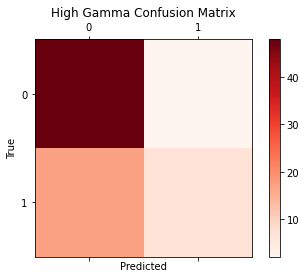

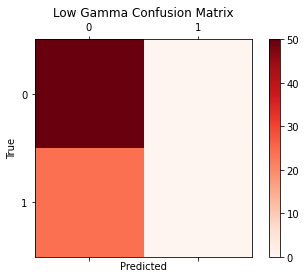

In [14]:
# YOUR CODE HERE

svm_high_gamma = SVC() 
svm_high_gamma.fit(X_train, Y_train)

svm_low_gamma = SVC(gamma=0.001, C=0.001)
svm_low_gamma.fit(X_train, Y_train)


y_val_pred_high = svm_high_gamma.predict(X_val)
y_val_pred_low = svm_low_gamma.predict(X_val)


cm_high = metrics.confusion_matrix(Y_val, y_val_pred_high, labels=[0,1])
cm_low = metrics.confusion_matrix(Y_val, y_val_pred_low, labels=[0,1])

print('High Gamma Confusion Matrix:\n', cm_high)
print('\nLow Gamma Confusion Matrix:\n', cm_low)

def show_cm(cm, title):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(cm, cmap='Reds')
    plt.title(title)
    fig.colorbar(cax)
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels([0,1])
    ax.set_yticklabels([0,1])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

show_cm(cm_high, 'High Gamma Confusion Matrix')
show_cm(cm_low, 'Low Gamma Confusion Matrix')